# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: XX     |  |
| :-------------|:-------------|
| Student naam 1| Annelinde Tijdhof 6327508 |
| Student naam 2| Student Studienummer 2 |
| Student naam 3| Student Studienummer 3 |
| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="tudelftLogo.png" alt="schets student 1" width="400"/>

![schets11def2](schets11def2.png "schets 1")

In [55]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

def capaciteit_plaatcondensator(A, d, epsilon_r):
    epsilon_0 = 8.854e-12
    capaciteit = epsilon_0 * epsilon_r * (A / d)
    return capaciteit
    


In [56]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

A = 0.1 * 0.1  # 
d = 0.003
epsilon_r = 2.5   

# Bereken capaciteit
C_F = capaciteit_plaatcondensator(A, d, epsilon_r)

# Omrekenen naar pF
C_pF = C_F * 1e12

print(f"Berekende capaciteit plaatcondensator groep XX is {C_pF:.1f} pF")


Berekende capaciteit plaatcondensator groep XX is 73.8 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](fotoplaatcondensator.HEIC)
![scope meting 2](tudelftLogo.png)

![foto](IMG_6012.jpeg) 
![foto](IMG_6016.jpeg) 


### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep XX| 100 pF | 0.503 V | 0.495 V | 98.5 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](tudelftLogo.png)
![foto](foto3schetsen.png) 

## Opdracht 3: Welke sensor gaan jullie maken?

Ik ga een sensor maken met het materiaal schuim ertussen en die dan door verandering in dikte door verandering in gewicht de capaciteit meet. 

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](eindschets.png)

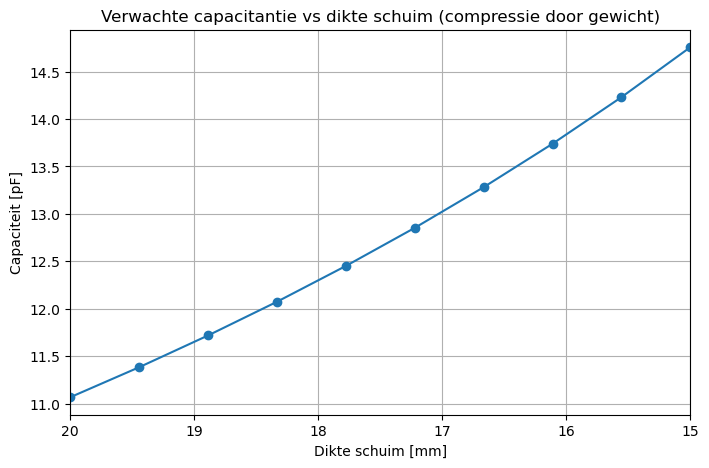

In [57]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

def capaciteit_plaatcondensator(A, d, epsilon_r):
    epsilon_0 = 8.854e-12  # F/m
    return epsilon_0 * epsilon_r * (A / d)

A = 0.10 * 0.10  
d_start = 0.02   
epsilon_r = 2.5  


d_variatie = np.linspace(d_start, 0.015, 10)  


C_variatie = []
for d in d_variatie:
    C = capaciteit_plaatcondensator(A, d, epsilon_r)
    C_variatie.append(C * 1e12)  


plt.figure(figsize=(8,5))
plt.plot(d_variatie*1000, C_variatie, marker='o')  
plt.title('Verwachte capacitantie vs dikte schuim (compressie door gewicht)')
plt.xlabel('Dikte schuim [mm]')
plt.ylabel('Capaciteit [pF]')
plt.grid(True)


plt.xlim(20, 15)

plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| ? |? |
| gemiddelde capaciteit| ? |? |
| maximale capaciteit| ? |? |

Ik heb een macbook en dit lukte niet dus kreeg opdracht van TA dit volgende keer met een TA te doen die wel macbooks snapt. Vandaar dat ik deze nog niet heb gedaan, ik ga zsm kijken met een macbook TA waar het fout gaat bij mij

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](IMG_6025.JPEG)
![meting 1](IMG_6028.JPEG)
![meting 2](IMG_6029.JPEG)
![meting 2](IMG_6030.JPEG)

## Opdracht 7: Plot de kalibratiegrafiek.

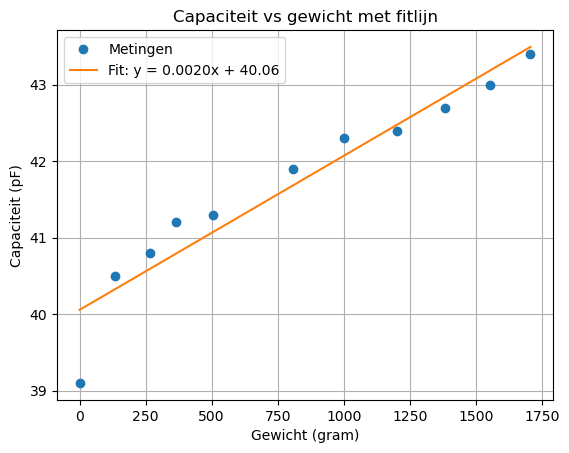

In [58]:


gewicht = np.array([0,136,265,365,507,808,1000,1202,1385,1554,1707])  # gram
capaciteit = np.array([39.1,40.5,40.8,41.2,41.3,41.9,42.3,42.4,42.7,43.0,43.4])  # pF


a, b = np.polyfit(gewicht, capaciteit, 1)

gewicht_fit = np.linspace(min(gewicht), max(gewicht), 100)
capaciteit_fit = a * gewicht_fit + b


plt.figure()
plt.plot(gewicht, capaciteit, 'o', label='Metingen')
plt.plot(gewicht_fit, capaciteit_fit, label=f'Fit: y = {a:.4f}x + {b:.2f}')

plt.xlabel('Gewicht (gram)')
plt.ylabel('Capaciteit (pF)')
plt.title('Capaciteit vs gewicht met fitlijn')
plt.grid(True)
plt.legend()

plt.show()

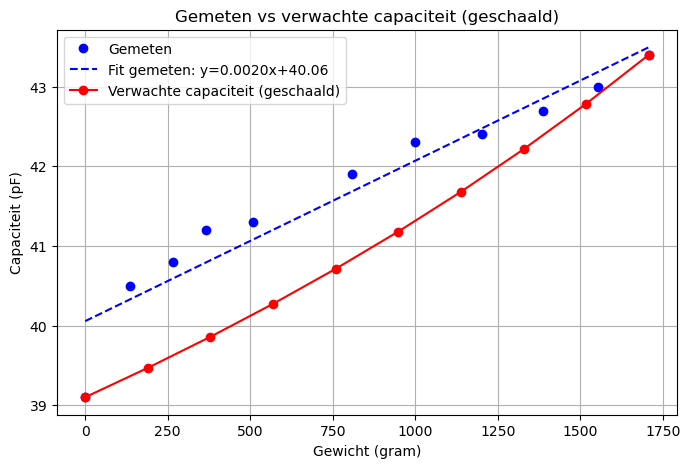

In [59]:

def capaciteit_plaatcondensator(A, d, epsilon_r):
    epsilon_0 = 8.854e-12  # F/m
    return epsilon_0 * epsilon_r * (A / d)


A = 0.10 * 0.10 
d_start = 0.02   
epsilon_r = 2.5  

d_variatie = np.linspace(d_start, 0.015, 10)  
C_variatie = capaciteit_plaatcondensator(A, d_variatie, epsilon_r) * 1e12  


gewicht = np.array([0,136,265,365,507,808,1000,1202,1385,1554,1707])  
capaciteit = np.array([39.1,40.5,40.8,41.2,41.3,41.9,42.3,42.4,42.7,43.0,43.4])  

a, b = np.polyfit(gewicht, capaciteit, 1)
gewicht_fit = np.linspace(min(gewicht), max(gewicht), 100)
capaciteit_fit = a * gewicht_fit + b


schaalfactor = (capaciteit[-1] - capaciteit[0]) / (C_variatie[-1] - C_variatie[0])
C_variatie_schaal = C_variatie * schaalfactor + capaciteit[0] - C_variatie[0]*schaalfactor


gewicht_proxy = np.linspace(min(gewicht), max(gewicht), len(C_variatie_schaal))


plt.figure(figsize=(8,5))

plt.plot(gewicht, capaciteit, 'o', label='Gemeten', color='blue')
plt.plot(gewicht_fit, capaciteit_fit, '--', label=f'Fit gemeten: y={a:.4f}x+{b:.2f}', color='blue')


plt.plot(gewicht_proxy, C_variatie_schaal, '-o', label='Verwachte capaciteit (geschaald)', color='red')

plt.xlabel('Gewicht (gram)')
plt.ylabel('Capaciteit (pF)')
plt.title('Gemeten vs verwachte capaciteit (geschaald)')
plt.grid(True)
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* schuim gelijkmatig laten indrukken
* meerdere metingen en dan gemiddelde 

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![meting 2](IMG_6031.JPEG)

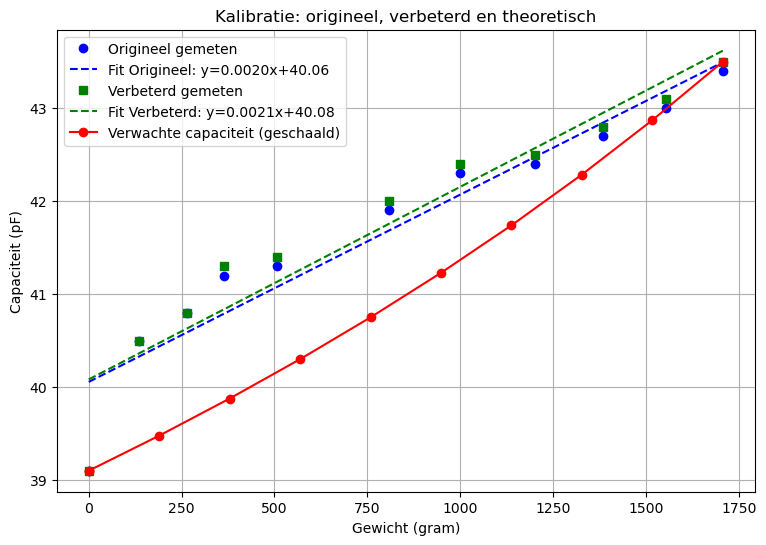

In [60]:

capaciteit_verbeterd = np.array([39.1,40.5,40.8,41.3,41.4,42.0,42.4,42.5,42.8,43.1,43.5])

a_verb, b_verb = np.polyfit(gewicht, capaciteit_verbeterd, 1)
capaciteit_fit_verb = a_verb * gewicht_fit + b_verb

schaalfactor = (capaciteit_verbeterd[-1] - capaciteit_verbeterd[0]) / (C_variatie[-1] - C_variatie[0])
C_variatie_schaal = C_variatie * schaalfactor + capaciteit_verbeterd[0] - C_variatie[0]*schaalfactor
gewicht_proxy = np.linspace(min(gewicht), max(gewicht), len(C_variatie_schaal))

plt.figure(figsize=(9,6))

plt.plot(gewicht, capaciteit_origineel, 'o', label='Origineel gemeten', color='blue')
plt.plot(gewicht_fit, capaciteit_fit_orig, '--', label=f'Fit Origineel: y={a_orig:.4f}x+{b_orig:.2f}', color='blue')

plt.plot(gewicht, capaciteit_verbeterd, 's', label='Verbeterd gemeten', color='green')
plt.plot(gewicht_fit, capaciteit_fit_verb, '--', label=f'Fit Verbeterd: y={a_verb:.4f}x+{b_verb:.2f}', color='green')

plt.plot(gewicht_proxy, C_variatie_schaal, '-o', label='Verwachte capaciteit (geschaald)', color='red')

plt.xlabel('Gewicht (gram)')
plt.ylabel('Capaciteit (pF)')
plt.title('Kalibratie: origineel, verbeterd en theoretisch')
plt.grid(True)
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

De sensor is geschikt om de verandering in capaciteit door gewicht te meten. De verbeteringen (uniforme compressie en gemiddelde van meerdere metingen) hebben de meetnauwkeurigheid verhoogd. Er zit nog een  verschil tussen de theoretische en gemeten waarden, door praktische effecten zoals schuimnonuniformiteit. De vlakke plaat formule geeft een redelijke schatting, maar houdt geen rekening met randeffecten en materiaalonregelmatigheden

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

opdracht 1,2,3,4

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

opdracht 1,6,9

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

opdracht 7,8,9